Dataset Shape: (150, 5)

Data Types & Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB
None

Missing Values Check:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Descriptive Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min            

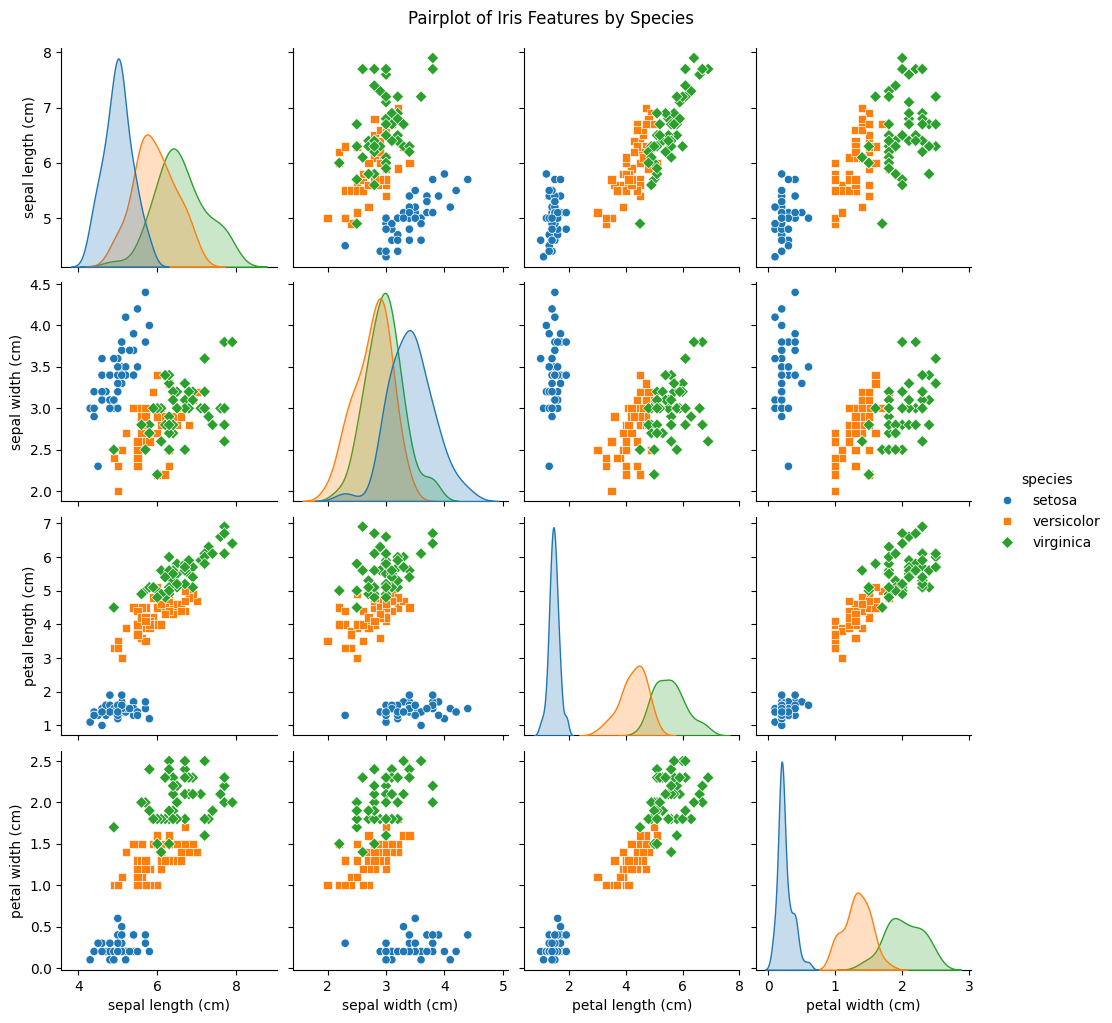

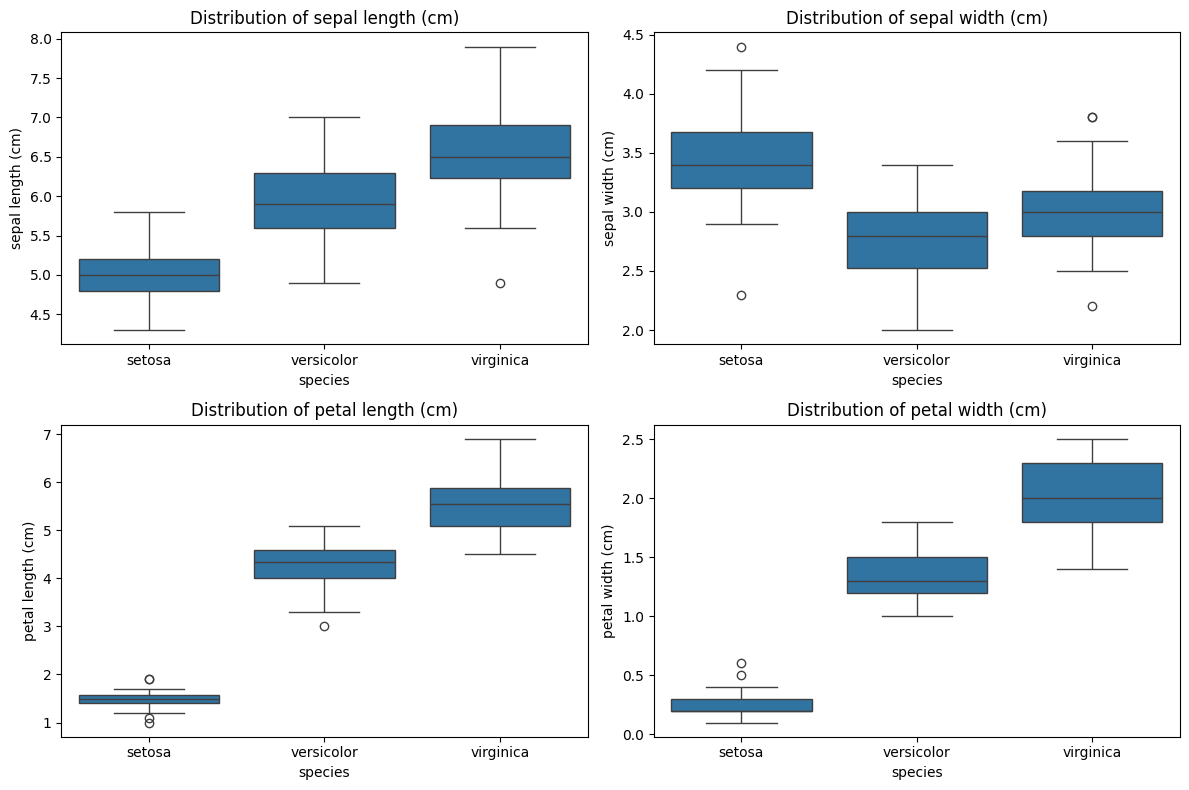


==================== K-Nearest Neighbors Evaluation ====================
Accuracy Score: 0.9333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

==================== Random Forest Evaluation ====================
Accuracy Score: 0.9000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
we

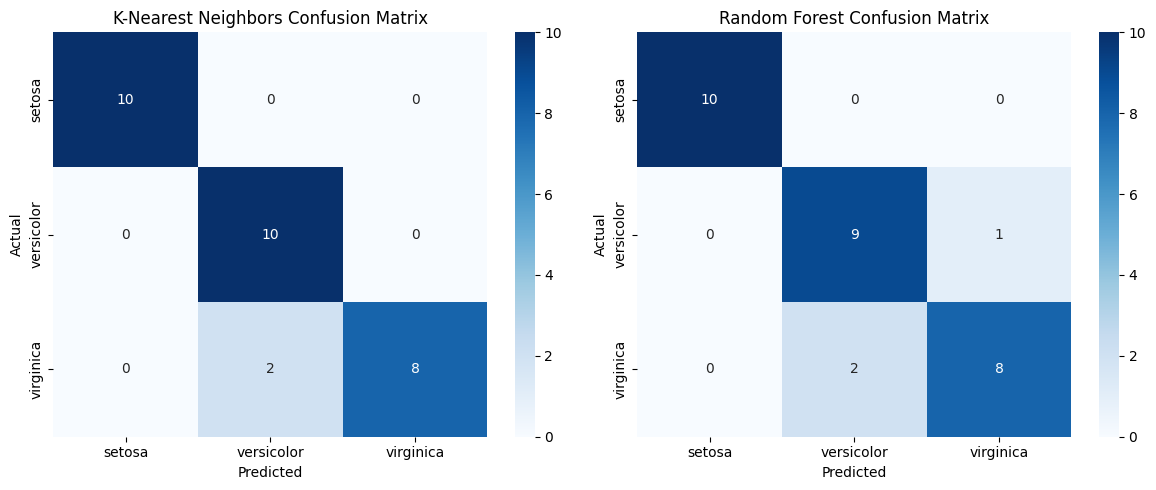

In [ ]:
# ==========================================
# 1. Imports & Dataset Loading
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Load the dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

# ==========================================
# 2. Exploratory Data Analysis (EDA)
# ==========================================
print("Dataset Shape:", df.shape)
print("\nData Types & Info:")
print(df.info())

print("\nMissing Values Check:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
print(df.describe())

# ==========================================
# 3. Visualizations
# ==========================================
# Pairplot: Feature distributions by species
sns.pairplot(df, hue="species", markers=["o", "s", "D"])
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

# Box plots for each feature
plt.figure(figsize=(12, 8))
for idx, feature in enumerate(iris.feature_names, 1):
    plt.subplot(2, 2, idx)
    sns.boxplot(x="species", y=feature, data=df)
    plt.title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

# ==========================================
# 4. Feature Selection Discussion
# ==========================================
# Based on the pairplot and box plots:
# - 'petal length (cm)' and 'petal width (cm)' are the most discriminative features.
# - Setosa is completely separable using petal dimensions alone.
# - Versicolor and Virginica have minimal overlap along petal length/width,
#   whereas sepal dimensions exhibit significant overlap across classes.

# ==========================================
# 5. Trahin/Test Split & Preprocessing
# ==========================================
X = df[iris.feature_names]
y = iris.target  # Target labels: 0, 1, 2

# 80/20 train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature scaling (recommended for distance-based models like KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 6. Train Classifiers
# ==========================================
# Classifier 1: K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# Classifier 2: Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# ==========================================
# 7. Model Evaluation Function
# ==========================================
models = {
    "K-Nearest Neighbors": (y_test, y_pred_knn),
    "Random Forest": (y_test, y_pred_rf),
}

for name, (true_vals, preds) in models.items():
    print(f"\n{'='*20} {name} Evaluation {'='*20}")
    print(f"Accuracy Score: {accuracy_score(true_vals, preds):.4f}")
    print("\nClassification Report:")
    print(classification_report(true_vals, preds, target_names=iris.target_names))
    print("Confusion Matrix:")
    print(confusion_matrix(true_vals, preds))

# Confusion Matrix Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, (true_vals, preds)) in zip(axes, models.items()):
    cm = confusion_matrix(true_vals, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=iris.target_names,
        yticklabels=iris.target_names,
        ax=ax,
    )
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()